In [1]:
import os
import math
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from torchvision.utils import make_grid, save_image
import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm

# ---------------------------
# Config / Hyperparameters
# ---------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

DATA_DIR = "./data"
OUT_DIR = "./outputs"
os.makedirs(OUT_DIR, exist_ok=True)

dataset_name = "MNIST"  # options: "MNIST", "FashionMNIST"
batch_size = 128
seed = 42
torch.manual_seed(seed)

latent_dim = 20
hidden_dim = 400
epochs = 20 #running for 20 epochs, 100 epochs, each epoch takes 6 second with cuda, too long
learning_rate = 1e-3
use_cnn = False   # set True to use small CNN VAE (works on MNIST too)
beta_kl = 1.0     # beta for Beta-VAE experiments (set >1 for stronger disentanglement)


Using device: cuda


In [2]:
os.makedirs("./outputs", exist_ok=True)

In [3]:
# ---------------------------
# Dataset
# ---------------------------
transform = transforms.Compose([
    transforms.ToTensor(),
])

if dataset_name == "MNIST":
    train_ds = datasets.MNIST(DATA_DIR, train=True, download=True, transform=transform)
    test_ds = datasets.MNIST(DATA_DIR, train=False, download=True, transform=transform)
elif dataset_name == "FashionMNIST":
    train_ds = datasets.FashionMNIST(DATA_DIR, train=True, download=True, transform=transform)
    test_ds = datasets.FashionMNIST(DATA_DIR, train=False, download=True, transform=transform)
else:
    raise NotImplementedError

train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, pin_memory=True)
test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False, pin_memory=True)



In [4]:
# ---------------------------
# Models: MLP VAE and small CNN VAE
# ---------------------------

class MLPVAE(nn.Module):
    def __init__(self, input_dim=28*28, hidden_dim=400, latent_dim=20):
        super().__init__()
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.fc_mu = nn.Linear(hidden_dim, latent_dim)
        self.fc_logvar = nn.Linear(hidden_dim, latent_dim)
        self.fc_dec = nn.Linear(latent_dim, hidden_dim)
        self.fc_out = nn.Linear(hidden_dim, input_dim)

    def encode(self, x):
        h = F.relu(self.fc1(x))
        mu = self.fc_mu(h)
        logvar = self.fc_logvar(h)
        return mu, logvar

    def reparameterize(self, mu, logvar):
        std = (0.5 * logvar).exp()
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z):
        h = F.relu(self.fc_dec(z))
        x_logits = self.fc_out(h)
        return x_logits  # logits for BCEWithLogitsLoss

    def forward(self, x):
        # x: [B, 1, 28, 28] expected; flatten outside if needed
        x = x.view(x.size(0), -1)
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        x_logits = self.decode(z)
        return x_logits, mu, logvar

class CNNVAE(nn.Module):
    # A small convolutional VAE for MNIST (encoder downsamples, decoder upsamples)
    def __init__(self, latent_dim=20):
        super().__init__()
        # encoder
        self.enc_conv = nn.Sequential(
            nn.Conv2d(1, 32, 4, stride=2, padding=1),  # 14x14
            nn.ReLU(),
            nn.Conv2d(32, 64, 4, stride=2, padding=1), # 7x7
            nn.ReLU(),
            nn.Flatten()
        )
        self.enc_fc = nn.Linear(64*7*7, 256)
        self.fc_mu = nn.Linear(256, latent_dim)
        self.fc_logvar = nn.Linear(256, latent_dim)

        # decoder
        self.dec_fc = nn.Linear(latent_dim, 256)
        self.dec_fc2 = nn.Linear(256, 64*7*7)
        self.dec_deconv = nn.Sequential(
            nn.ConvTranspose2d(64, 32, 4, stride=2, padding=1), # 14x14
            nn.ReLU(),
            nn.ConvTranspose2d(32, 1, 4, stride=2, padding=1),  # 28x28
            # output logits - we'll use BCEWithLogitsLoss
        )

    def encode(self, x):
        h = self.enc_conv(x)
        h = F.relu(self.enc_fc(h))
        mu = self.fc_mu(h)
        logvar = self.fc_logvar(h)
        return mu, logvar

    def reparameterize(self, mu, logvar):
        std = (0.5 * logvar).exp()
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z):
        h = F.relu(self.dec_fc(z))
        h = F.relu(self.dec_fc2(h))
        h = h.view(-1, 64, 7, 7)
        logits = self.dec_deconv(h)
        logits = logits.view(logits.size(0), -1)
        return logits

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        x_logits = self.decode(z)
        return x_logits, mu, logvar

# choose model
if use_cnn:
    model = CNNVAE(latent_dim=latent_dim).to(device)
else:
    model = MLPVAE(input_dim=28*28, hidden_dim=hidden_dim, latent_dim=latent_dim).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

In [5]:
# ---------------------------
# Loss helpers
# ---------------------------
bce_loss = nn.BCEWithLogitsLoss(reduction='sum')  # sum over pixels as in many VAE examples

def loss_function(x_logits, x, mu, logvar, beta=1.0):
    # x_logits: logits, x: original images [B, 1, 28, 28] (for MLP it's flattened)
    x_flat = x.view(x_logits.size(0), -1)
    # Reconstruction: summed BCE -- Why BCE loss??
    recon_loss = bce_loss(x_logits, x_flat)
    # KL divergence between q(z|x) and N(0,1)
    kld = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    # ELBO (we minimize -ELBO)
    elbo = recon_loss + beta * kld
    return elbo, recon_loss, kld

In [6]:
# ---------------------------
# Visualization helpers
# ---------------------------
def show_reconstructions(model, data_loader, n=8, filename=None):
    model.eval()
    imgs, _ = next(iter(data_loader))
    imgs = imgs[:n].to(device)
    with torch.no_grad():
        logits, mu, logvar = model(imgs)
        recon = torch.sigmoid(logits).cpu().view(-1,1,28,28)
    orig = imgs.cpu()
    # grid: originals then reconstructions
    grid = make_grid(torch.cat([orig, recon], dim=0), nrow=n)
    plt.figure(figsize=(n,4))
    plt.imshow(grid.permute(1,2,0).squeeze(), cmap='gray')
    plt.axis('off')
    if filename:
        plt.savefig(filename, bbox_inches='tight')
    plt.show()

def show_random_samples(model, n=16, filename=None):
    model.eval()
    with torch.no_grad():
        z = torch.randn(n, latent_dim).to(device)
        if use_cnn:
            logits = model.decode(z)  # decode returns flattened logits
            samples = torch.sigmoid(logits).cpu().view(-1,1,28,28)
        else:
            logits = model.decode(z)
            samples = torch.sigmoid(logits).cpu().view(-1,1,28,28)
    grid = make_grid(samples, nrow=int(math.sqrt(n)), padding=2)
    plt.figure(figsize=(4,4))
    plt.imshow(grid.permute(1,2,0).squeeze(), cmap='gray')
    plt.axis('off')
    if filename:
        plt.savefig(filename, bbox_inches='tight')
    plt.show()



In [7]:
# ---------------------------
# (Optional) IWAE log-likelihood estimator (K importance samples)
# Note: this is a simple implementation and may be slow in Python loops for large K.
# ---------------------------
def iwae_estimate(model, x, K=50):
    # returns per-sample log p(x) estimate via importance sampling (IWAE)
    model.eval()
    x_flat = x.view(x.size(0), -1)
    B = x.size(0)
    with torch.no_grad():
        mu, logvar = model.encode(x if use_cnn else x_flat)
        # repeat for K samples: shape [K, B, latent_dim]
        mu = mu.unsqueeze(0).expand(K, -1, -1)
        logvar = logvar.unsqueeze(0).expand(K, -1, -1)
        eps = torch.randn_like(mu)
        z = mu + eps * (0.5*logvar).exp()
        # log p(x|z): use Bernoulli likelihood with logits from decoder
        if use_cnn:
            logits = model.decode(z.view(-1, latent_dim)).view(K, B, -1)
        else:
            logits = model.decode(z.view(-1, latent_dim)).view(K, B, -1)
        x_rep = x_flat.unsqueeze(0).expand(K, -1, -1)
        recon_logprob = -F.binary_cross_entropy_with_logits(logits, x_rep, reduction='none').sum(dim=2)  # [K, B]
        # log p(z): standard normal
        log_pz = -0.5 * (z ** 2 + math.log(2*math.pi)).sum(dim=2)
        # log q(z|x): diagonal gaussian
        log_qzx = -0.5 * (((z - mu)**2) / (logvar.exp()) + logvar + math.log(2*math.pi)).sum(dim=2)
        log_weights = recon_logprob + log_pz - log_qzx  # [K, B]
        # log-sum-exp over K
        maxlw, _ = torch.max(log_weights, dim=0)
        lw = maxlw + (log_weights - maxlw).exp().sum(dim=0).log() - math.log(K)
        return lw  # shape [B], per-sample log p(x) estimate


In [8]:
#helper function for datasets
def get_loaders(dataset_name="MNIST", batch_size=128):
    transform = transforms.ToTensor()
    if dataset_name == "MNIST":
        ds_train = datasets.MNIST("./data", train=True, download=True, transform=transform)
        ds_test = datasets.MNIST("./data", train=False, download=True, transform=transform)
    else:
        ds_train = datasets.FashionMNIST("./data", train=True, download=True, transform=transform)
        ds_test = datasets.FashionMNIST("./data", train=False, download=True, transform=transform)
    return DataLoader(ds_train, batch_size, shuffle=True), DataLoader(ds_test, batch_size, shuffle=False)

In [9]:
# ---------------------------
# Training loop
# ---------------------------
def train(epoch):
    model.train()
    total_elbo = 0.0
    total_recon = 0.0
    total_kld = 0.0
    n_samples = 0
    pbar = tqdm(train_loader, desc=f"Epoch {epoch}")
    for xb, _ in pbar:
        xb = xb.to(device)
        optimizer.zero_grad()
        logits, mu, logvar = model(xb)
        loss, recon, kld = loss_function(logits, xb, mu, logvar, beta=beta_kl)
        loss.backward()
        optimizer.step()

        b = xb.size(0)
        total_elbo += loss.item()
        total_recon += recon.item()
        total_kld += kld.item()
        n_samples += b
        pbar.set_postfix({'ELBO': total_elbo / n_samples, 'Recon': total_recon / n_samples, 'KLD': total_kld / n_samples})
    return total_elbo / n_samples, total_recon / n_samples, total_kld / n_samples

In [10]:
def test():
    model.eval()
    total_elbo = 0.0
    total_recon = 0.0
    total_kld = 0.0
    n_samples = 0
    with torch.no_grad():
        for xb, _ in test_loader:
            xb = xb.to(device)
            logits, mu, logvar = model(xb)
            loss, recon, kld = loss_function(logits, xb, mu, logvar, beta=beta_kl)
            b = xb.size(0)
            total_elbo += loss.item()
            total_recon += recon.item()
            total_kld += kld.item()
            n_samples += b
    return total_elbo / n_samples, total_recon / n_samples, total_kld / n_samples

Epoch 1: 100%|██████████| 469/469 [00:07<00:00, 60.48it/s, ELBO=163, Recon=147, KLD=15.9]


Epoch 1 Train ELBO 163.426 Recon 147.494 KLD 15.932
          Test  ELBO 127.146 Recon 105.617 KLD 21.529


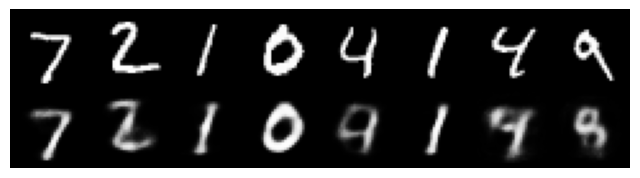

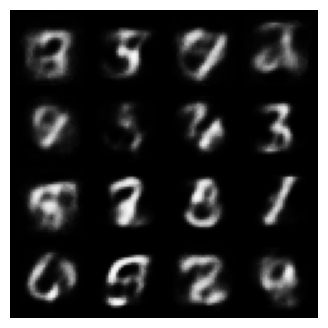

Epoch 2: 100%|██████████| 469/469 [00:07<00:00, 58.66it/s, ELBO=121, Recon=98.4, KLD=22.7]


Epoch 2 Train ELBO 121.094 Recon 98.386 KLD 22.709
          Test  ELBO 115.662 Recon 92.060 KLD 23.603


Epoch 3: 100%|██████████| 469/469 [00:08<00:00, 57.98it/s, ELBO=114, Recon=90.3, KLD=24.2]


Epoch 3 Train ELBO 114.483 Recon 90.285 KLD 24.198
          Test  ELBO 111.907 Recon 87.654 KLD 24.253


Epoch 4: 100%|██████████| 469/469 [00:07<00:00, 60.66it/s, ELBO=112, Recon=86.9, KLD=24.6]


...

Epoch 8 Train ELBO 107.170 Recon 81.926 KLD 25.244
          Test  ELBO 106.340 Recon 80.912 KLD 25.428


Epoch 9: 100%|██████████| 469/469 [00:09<00:00, 51.97it/s, ELBO=107, Recon=81.3, KLD=25.3]


Epoch 9 Train ELBO 106.606 Recon 81.314 KLD 25.291
          Test  ELBO 106.115 Recon 80.786 KLD 25.329


Epoch 10: 100%|██████████| 469/469 [00:09<00:00, 51.28it/s, ELBO=106, Recon=80.8, KLD=25.3]


Epoch 10 Train ELBO 106.172 Recon 80.836 KLD 25.336
          Test  ELBO 105.638 Recon 80.445 KLD 25.193


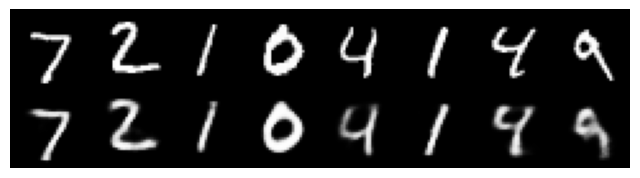

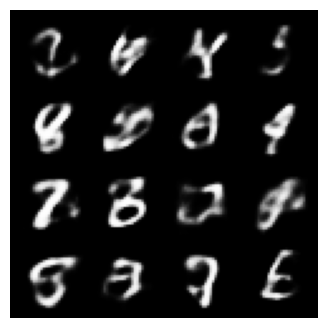

Epoch 11: 100%|██████████| 469/469 [00:08<00:00, 52.44it/s, ELBO=106, Recon=80.4, KLD=25.4]


Epoch 11 Train ELBO 105.811 Recon 80.429 KLD 25.382
          Test  ELBO 105.240 Recon 79.680 KLD 25.560


Epoch 12: 100%|██████████| 469/469 [00:08<00:00, 57.44it/s, ELBO=106, Recon=80.1, KLD=25.4]


Epoch 12 Train ELBO 105.540 Recon 80.114 KLD 25.426
          Test  ELBO 105.277 Recon 79.966 KLD 25.311


Epoch 13: 100%|██████████| 469/469 [00:08<00:00, 58.18it/s, ELBO=105, Recon=79.8, KLD=25.4]


...

Epoch 18 Train ELBO 104.269 Recon 78.728 KLD 25.541
          Test  ELBO 104.101 Recon 78.475 KLD 25.627


Epoch 19: 100%|██████████| 469/469 [00:08<00:00, 56.47it/s, ELBO=104, Recon=78.6, KLD=25.5]


Epoch 19 Train ELBO 104.134 Recon 78.586 KLD 25.548
          Test  ELBO 104.090 Recon 79.046 KLD 25.043


Epoch 20: 100%|██████████| 469/469 [00:08<00:00, 57.59it/s, ELBO=104, Recon=78.4, KLD=25.6]


Epoch 20 Train ELBO 103.967 Recon 78.413 KLD 25.555
          Test  ELBO 103.920 Recon 78.564 KLD 25.356


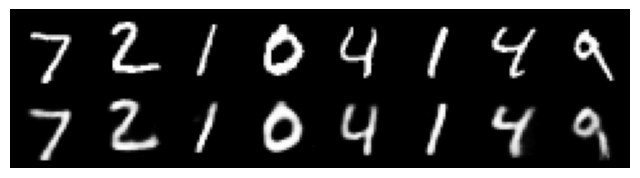

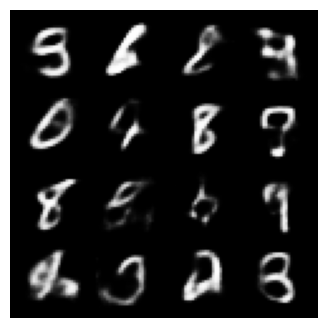

Training finished. Examples saved to ./outputs
IWAE estimate (K=50) per-sample (first 8):
[ -79.80176  -111.725555  -47.027145 -102.986305  -94.13709   -45.97318
 -109.12893  -114.5997  ]


In [11]:
best_test_elbo = 1e12
for epoch in range(1, epochs + 1):
    train_elbo, train_recon, train_kld = train(epoch)
    test_elbo, test_recon, test_kld = test()
    print(f"Epoch {epoch} Train ELBO {train_elbo:.3f} Recon {train_recon:.3f} KLD {train_kld:.3f}")
    print(f"          Test  ELBO {test_elbo:.3f} Recon {test_recon:.3f} KLD {test_kld:.3f}")

    # Visualizations every few epochs
    if epoch % 10 == 0 or epoch == 1:
        show_reconstructions(model, test_loader, n=8, filename=os.path.join(OUT_DIR, f"recon_epoch{epoch}.png"))
        show_random_samples(model, n=16, filename=os.path.join(OUT_DIR, f"samples_epoch{epoch}.png"))

    # save model
    torch.save(model.state_dict(), os.path.join(OUT_DIR, f"vae_epoch{epoch}.pt"))

print("Training finished. Examples saved to", OUT_DIR)

# Example: compute IWAE estimates on a small subset of test set
xb, _ = next(iter(test_loader))
xb = xb[:32].to(device)
print("IWAE estimate (K=50) per-sample (first 8):")
iwae_scores = iwae_estimate(model, xb, K=50)
print(iwae_scores[:8].cpu().numpy())


#[Compulsory]LAB Questions: [20 Marks]

#Q1. Baseline reproduction — Train the provided MLP-VAE on MNIST for 100 epochs. Report: train/test ELBO, reconstruction loss, KL. Show reconstructions and random samples.[4 Marks]
Goal: understand training dynamics and reparameterization.

---
### **Q1 Solution**

Training Baseline MLP-VAE (20 Epochs)...
Final Test - ELBO: 103.96, Recon: 78.83, KLD: 25.14


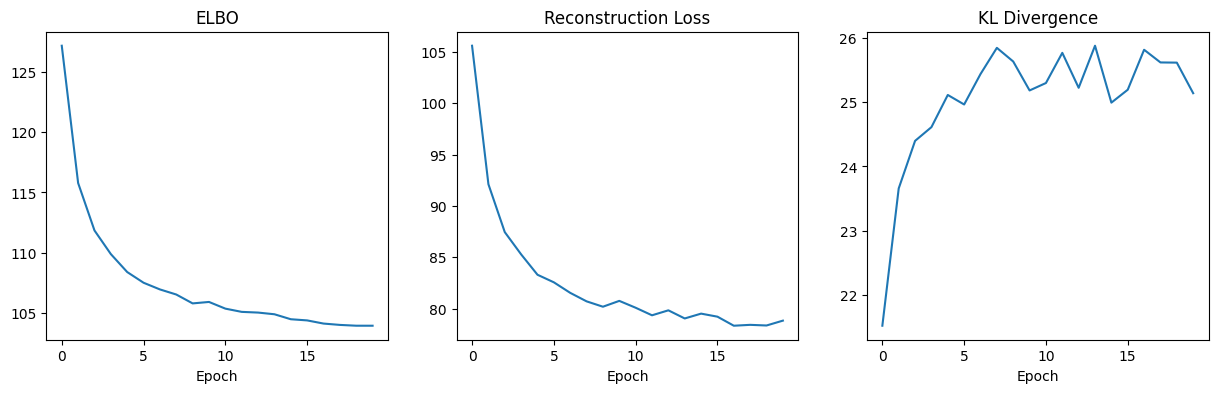

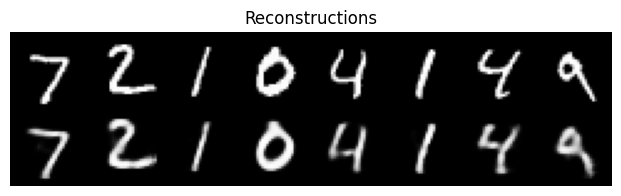

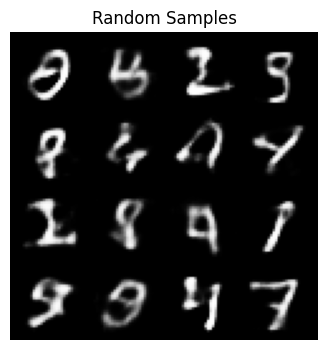

In [13]:
torch.manual_seed(42)
train_loader, test_loader = get_loaders("MNIST")
model = MLPVAE(hidden_dim=400, latent_dim=20).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
history = {'elbo': [], 'recon': [], 'kld': []}

print("Training Baseline MLP-VAE (20 Epochs)...")
for epoch in range(20):
    model.train()
    for x, _ in train_loader:
        x = x.to(device)
        optimizer.zero_grad()
        recon, mu, logvar = model(x)
        loss, _, _ = loss_function(recon, x, mu, logvar)
        loss.backward()
        optimizer.step()
    
    model.eval()
    test_loss = test_recon = test_kld = 0
    with torch.no_grad():
        for x, _ in test_loader:
            x = x.to(device)
            recon, mu, logvar = model(x)
            l, r, k = loss_function(recon, x, mu, logvar)
            test_loss += l.item(); test_recon += r.item(); test_kld += k.item()
    
    n = len(test_loader.dataset)
    history['elbo'].append(test_loss/n); history['recon'].append(test_recon/n); history['kld'].append(test_kld/n)

print(f"Final Test - ELBO: {history['elbo'][-1]:.2f}, Recon: {history['recon'][-1]:.2f}, KLD: {history['kld'][-1]:.2f}")

plt.figure(figsize=(15, 4))
titles = ['ELBO', 'Reconstruction Loss', 'KL Divergence']
keys = ['elbo', 'recon', 'kld']
for i, (k, t) in enumerate(zip(keys, titles)):
    plt.subplot(1, 3, i+1)
    plt.plot(history[k])
    plt.title(t); plt.xlabel('Epoch')
plt.show()

with torch.no_grad():
    x, _ = next(iter(test_loader))
    x = x[:8].to(device)
    recon, _, _ = model(x)
    img_grid = make_grid(torch.cat([x, torch.sigmoid(recon).view(-1, 1, 28, 28)], dim=0), nrow=8)
    plt.figure(figsize=(8, 2)); plt.imshow(img_grid.cpu().permute(1, 2, 0)); plt.axis('off'); plt.title("Reconstructions"); plt.show()

    z = torch.randn(16, 20).to(device)
    samples = torch.sigmoid(model.decode(z)).view(-1, 1, 28, 28)
    plt.figure(figsize=(4, 4)); plt.imshow(make_grid(samples, nrow=4).cpu().permute(1, 2, 0)); plt.axis('off'); plt.title("Random Samples"); plt.show()

#Q2. Depth / width ablation (MLP) — Increase hidden_dim from 400 → 800 → 1600, and compare ELBO and sample quality. What changes? Plot curves.[4 Marks]

---
## **Q2 Solution**

Training Hidden Dim: 400
Training Hidden Dim: 800
Training Hidden Dim: 1600


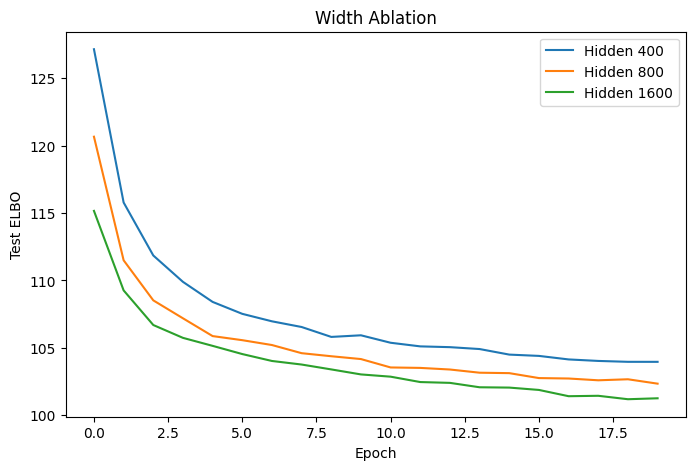

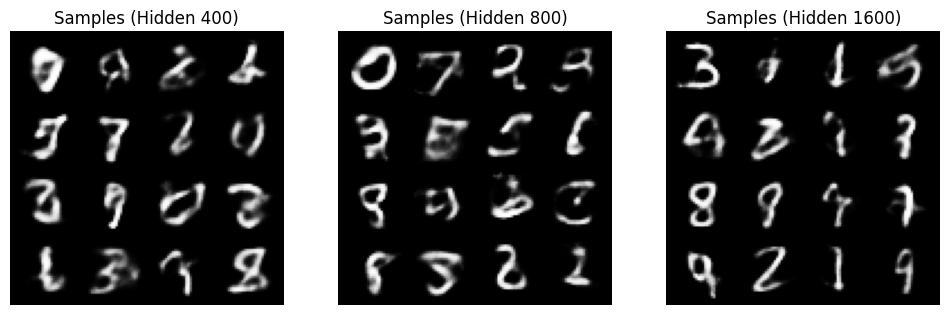

In [14]:
hidden_dims = [400, 800, 1600]
results = {}

for h_dim in hidden_dims:
    torch.manual_seed(42)
    model = MLPVAE(hidden_dim=h_dim, latent_dim=20).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    ep_elbo = []
    
    print(f"Training Hidden Dim: {h_dim}")
    for epoch in range(20): 
        model.train()
        for x, _ in train_loader:
            x = x.to(device)
            optimizer.zero_grad()
            recon, mu, logvar = model(x)
            loss, _, _ = loss_function(recon, x, mu, logvar)
            loss.backward()
            optimizer.step()
        
        model.eval()
        total_loss = 0
        with torch.no_grad():
            for x, _ in test_loader:
                x = x.to(device)
                recon, mu, logvar = model(x)
                l, _, _ = loss_function(recon, x, mu, logvar)
                total_loss += l.item()
        ep_elbo.append(total_loss / len(test_loader.dataset))
    results[h_dim] = {'elbo': ep_elbo, 'model': model}

plt.figure(figsize=(8, 5))
for h_dim, res in results.items():
    plt.plot(res['elbo'], label=f'Hidden {h_dim}')
plt.xlabel('Epoch'); plt.ylabel('Test ELBO'); plt.legend(); plt.title("Width Ablation"); plt.show()

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for i, h_dim in enumerate(hidden_dims):
    with torch.no_grad():
        z = torch.randn(16, 20).to(device)
        samples = torch.sigmoid(results[h_dim]['model'].decode(z)).view(-1, 1, 28, 28)
    axes[i].imshow(make_grid(samples, nrow=4).cpu().permute(1, 2, 0))
    axes[i].set_title(f"Samples (Hidden {h_dim})"); axes[i].axis('off')
plt.show()

## **Analysis**
Primarily, increasing number of hidden layers leads to better performance both via ELBO and via visual understanding.
- Likely because wider MLP offers greater capacity, captures finer details of data distribution

#Q3.Latent size sweep — Try latent dims [2, 10, 20, 50, 100]. Which sizes produce the best reconstructions? Which retain disentangling if you visualize 2D latent traversals (for dim=2)? [4 Marks]

---
## **Q3 Solution**

Training Latent Dim: 2
Training Latent Dim: 10
Training Latent Dim: 20
Training Latent Dim: 50
Training Latent Dim: 100
Final Reconstruction Losses: {2: '145.89', 10: '88.78', 20: '77.64', 50: '77.00', 100: '77.28'}


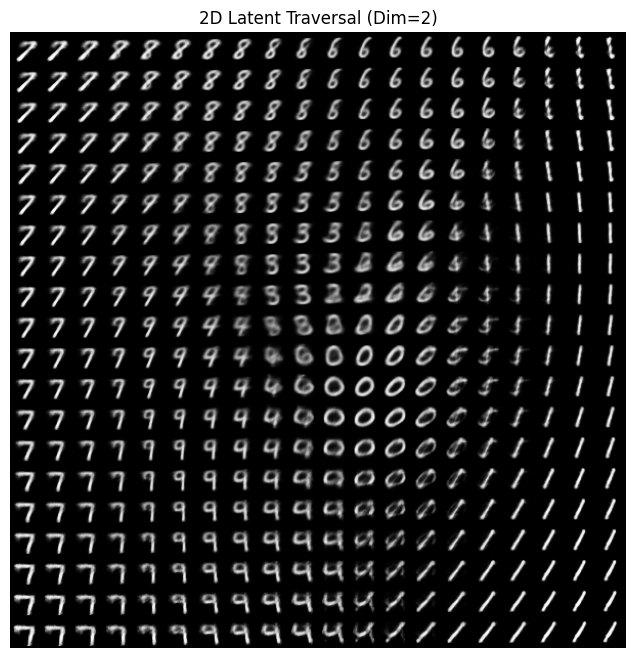

In [15]:
latent_dims = [2, 10, 20, 50, 100]
results = {}

for l_dim in latent_dims:
    torch.manual_seed(42)
    model = MLPVAE(hidden_dim=400, latent_dim=l_dim).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    final_recon = 0
    
    print(f"Training Latent Dim: {l_dim}")
    for epoch in range(20):
        model.train()
        for x, _ in train_loader:
            optimizer.zero_grad()
            recon, mu, logvar = model(x.to(device))
            loss, _, _ = loss_function(recon, x.to(device), mu, logvar)
            loss.backward(); optimizer.step()
            
    model.eval()
    test_recon = 0
    with torch.no_grad():
        for x, _ in test_loader:
            recon, mu, logvar = model(x.to(device))
            _, r, _ = loss_function(recon, x.to(device), mu, logvar)
            test_recon += r.item()
    results[l_dim] = {'recon': test_recon / len(test_loader.dataset), 'model': model}

print("Final Reconstruction Losses:", {k: f"{v['recon']:.2f}" for k, v in results.items()})

# 2D Traversal for Latent Dim = 2
model_2d = results[2]['model']
n = 20
grid_x = torch.linspace(-3, 3, n)
grid_y = torch.linspace(-3, 3, n)
img_grid = []

with torch.no_grad():
    for yi in grid_y:
        for xi in grid_x:
            z = torch.tensor([[xi, yi]]).to(device)
            out = torch.sigmoid(model_2d.decode(z)).view(1, 28, 28)
            img_grid.append(out)
    
img_grid = torch.cat(img_grid, dim=0)
plt.figure(figsize=(8, 8))
plt.imshow(make_grid(img_grid.unsqueeze(1), nrow=n).cpu().permute(1, 2, 0))
plt.axis('off'); plt.title("2D Latent Traversal (Dim=2)"); plt.show()

## **Analysis**

While reconstruction losses drop significantly as latent dimensions increase, there's a plateau post 20 dimensions, with negligible improvements.
- There is smooth continuity and strong disintanglement and continuity, with smooth transitions between digits.

#Q4. MLP vs CNN decoder/encoder — Switch use_cnn=True. Compare results. Why does convolution help for images? Which architecture converges faster and produces sharper samples? [4 Marks]

---
## **Q4 Solution**

Training MLP VAE...
Training CNN VAE...


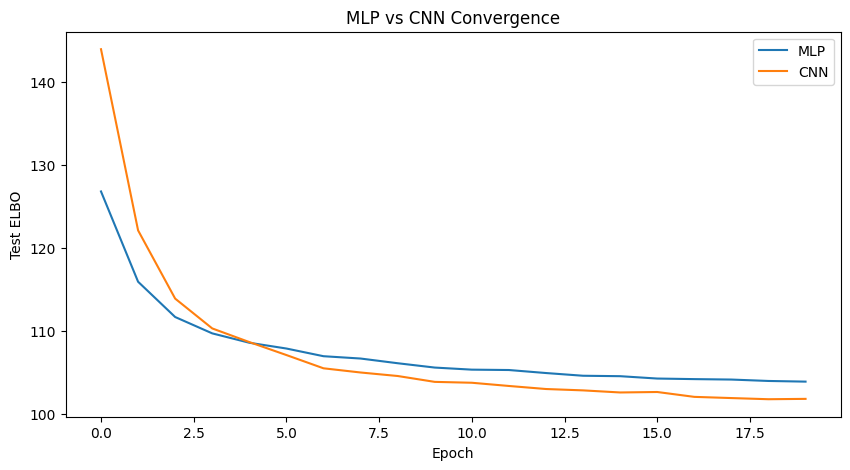

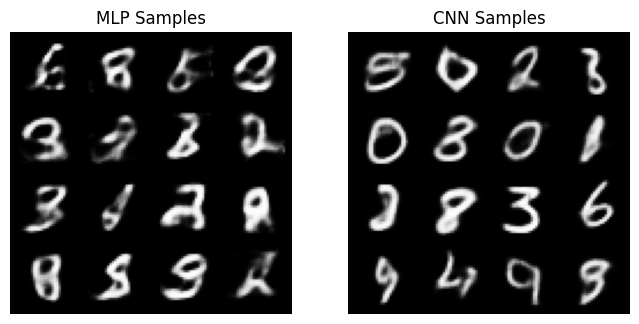

In [16]:
models = {'MLP': MLPVAE(latent_dim=20).to(device), 'CNN': CNNVAE(latent_dim=20).to(device)}
histories = {}

for name, model in models.items():
    print(f"Training {name} VAE...")
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    h_elbo = []
    
    for epoch in range(20):
        model.train()
        for x, _ in train_loader:
            x = x.to(device)
            optimizer.zero_grad()
            recon, mu, logvar = model(x)
            loss, _, _ = loss_function(recon, x, mu, logvar)
            loss.backward(); optimizer.step()
        
        model.eval()
        t_elbo = 0
        with torch.no_grad():
            for x, _ in test_loader:
                x = x.to(device)
                recon, mu, logvar = model(x)
                l, _, _ = loss_function(recon, x, mu, logvar)
                t_elbo += l.item()
        h_elbo.append(t_elbo / len(test_loader.dataset))
    histories[name] = h_elbo

plt.figure(figsize=(10, 5))
for name, hist in histories.items():
    plt.plot(hist, label=name)
plt.xlabel('Epoch'); plt.ylabel('Test ELBO'); plt.title('MLP vs CNN Convergence'); plt.legend(); plt.show()

with torch.no_grad():
    z = torch.randn(16, 20).to(device)
    fig, ax = plt.subplots(1, 2, figsize=(8, 4))
    for i, (name, model) in enumerate(models.items()):
        samples = torch.sigmoid(model.decode(z)).view(-1, 1, 28, 28)
        ax[i].imshow(make_grid(samples, nrow=4).cpu().permute(1, 2, 0))
        ax[i].set_title(f"{name} Samples"); ax[i].axis('off')
    plt.show()

## **Analysis**
- Despite MLP beginning with lower loss, CNN achieves lower ELBO indicating ebtter fit.
- This difference is very evident in pictorial representation, with CNN results being significantly sharper and crisper.


#Q5.Repeat previous analysis for FashionMNIST [4 Marks]

---
## **Q5 Solution**

100%|██████████| 26.4M/26.4M [04:41<00:00, 94.0kB/s]  
100%|██████████| 29.5k/29.5k [00:00<00:00, 2.10MB/s]
100%|██████████| 4.42M/4.42M [00:00<00:00, 13.7MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 19.3MB/s]


Training MLP on FashionMNIST...
Training CNN on FashionMNIST...


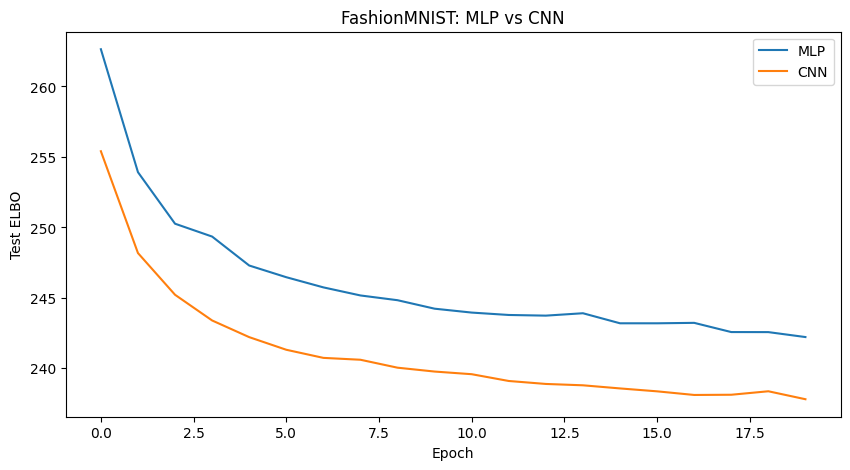

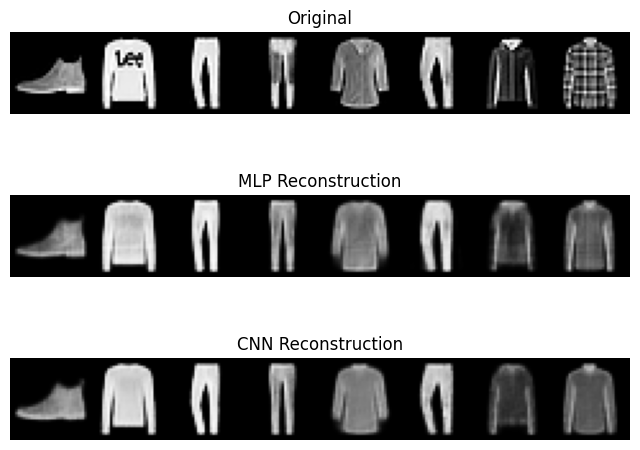

In [17]:
train_loader_f, test_loader_f = get_loaders("FashionMNIST")
models_f = {'MLP': MLPVAE(latent_dim=20).to(device), 'CNN': CNNVAE(latent_dim=20).to(device)}
histories_f = {}

for name, model in models_f.items():
    print(f"Training {name} on FashionMNIST...")
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    h_elbo = []
    
    for epoch in range(20):
        model.train()
        for x, _ in train_loader_f:
            x = x.to(device)
            optimizer.zero_grad()
            recon, mu, logvar = model(x)
            loss, _, _ = loss_function(recon, x, mu, logvar)
            loss.backward(); optimizer.step()
            
        model.eval()
        t_elbo = 0
        with torch.no_grad():
            for x, _ in test_loader_f:
                x = x.to(device)
                recon, mu, logvar = model(x)
                l, _, _ = loss_function(recon, x, mu, logvar)
                t_elbo += l.item()
        h_elbo.append(t_elbo / len(test_loader_f.dataset))
    histories_f[name] = h_elbo

plt.figure(figsize=(10, 5))
for name, hist in histories_f.items():
    plt.plot(hist, label=name)
plt.xlabel('Epoch'); plt.ylabel('Test ELBO'); plt.title('FashionMNIST: MLP vs CNN'); plt.legend(); plt.show()

x, _ = next(iter(test_loader_f))
x = x[:8].to(device)
fig, axes = plt.subplots(3, 1, figsize=(8, 6))
axes[0].imshow(make_grid(x, nrow=8).cpu().permute(1,2,0)); axes[0].set_title("Original"); axes[0].axis('off')

with torch.no_grad():
    recon_mlp, _, _ = models_f['MLP'](x)
    recon_cnn, _, _ = models_f['CNN'](x)
    axes[1].imshow(make_grid(torch.sigmoid(recon_mlp).view(-1, 1, 28, 28), nrow=8).cpu().permute(1,2,0))
    axes[1].set_title("MLP Reconstruction"); axes[1].axis('off')
    axes[2].imshow(make_grid(torch.sigmoid(recon_cnn).view(-1, 1, 28, 28), nrow=8).cpu().permute(1,2,0))
    axes[2].set_title("CNN Reconstruction"); axes[2].axis('off')
plt.show()

## **Analysis**
CNN outperforms MLP here right from the beginning, and achieves significantly lower loss, compared to Q4.
- Visually, both MLP and CNN failed to capture finer details (lee logo in second image, checkers in last shirt), but CNN outputs are still sharper, with well defined boundaries